In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset
This project uses the NYC Building Energy and Water Disclosure dataset for calendar years 2022 to present. 
Since all team members use the same dataset but study different subproblems, this shared EDA establishes a common understanding of the dataset structure, data quality, and shared preprocessing rules.

In [4]:
file_path = "NYC_Building_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2023_to_Present_(Data_for_Calendar_Year_2022-Present)_20260329.csv"
df = pd.read_csv(file_path, low_memory=False)

In [6]:
print("Shape:", df.shape)

Shape: (103259, 265)


In [8]:
df.head()

,Calendar Year,Property ID,Property Name,Parent Property ID,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Address 1,City,...,Aggregate Meter(s)-District Steam – Number of Individual Meters Included,Report Generation Date,Report Submission Date,Borough,Latitude,Longitude,Community Board,Council District,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4026780001,4059918,58-01 Grand Avenue,Queens,...,NaN,04/25/2023 11:01:00 AM,04/25/2023 11:02:00 AM,QUEENS,40.719667,-73.911197,405.0,30.0,531.0,QN0501
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,2042500026,2047795,1870 Pelham Parkway South,Bronx,...,NaN,03/11/2023 02:00:00 PM,03/11/2023 02:01:00 PM,BRONX,40.855488,-73.830726,210.0,13.0,300.0,BX1003
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4157040040,4300145,2011 Mott Ave,Far Rockaway,...,NaN,04/14/2023 03:47:00 PM,04/14/2023 03:47:00 PM,QUEENS,40.604320,-73.753009,414.0,31.0,100803.0,QN1401
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,1016490009,1052383,215 East 99th Street,New York,...,NaN,03/12/2023 03:54:00 PM,03/12/2023 03:54:00 PM,MANHATTAN,40.786963,-73.947537,111.0,8.0,164.0,MN1101
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4008350027,4017180,23-25 31 Street,Queens,...,NaN,04/28/2023 02:22:00 PM,04/28/2023 02:23:00 PM,QUEENS,40.773768,-73.913573,401.0,22.0,115.0,QN0101


In [10]:
print("\nColumn sample:")
print(df.columns.tolist()[:30])


Column sample:
['Calendar Year', 'Property ID', 'Property Name', 'Parent Property ID', 'Parent Property Name', 'Year Ending', 'NYC Borough, Block and Lot (BBL)', 'NYC Building Identification Number (BIN)', 'Address 1', 'City', 'Postal Code', 'Primary Property Type - Self Selected', 'Primary Property Type - Portfolio Manager-Calculated', 'National Median Reference Property Type', 'List of All Property Use Types (GFA) (ft²)', 'Largest Property Use Type', 'Largest Property Use Type - Gross Floor Area (ft²)', '2nd Largest Property Use Type', '2nd Largest Property Use Type - Gross Floor Area (ft²)', '3rd Largest Property Use Type', '3rd Largest Property Use Type - Gross Floor Area (ft²)', 'Year Built', 'Construction Status', 'Number of Buildings', 'Occupancy', 'Metered Areas (Energy)', 'Metered Areas (Water)', 'ENERGY STAR Score', 'National Median ENERGY STAR Score', 'Target ENERGY STAR Score']


### 2. Data Types and Rough Column Categories

In [13]:
dtype_summary = df.dtypes.value_counts()
dtype_summary

object     248
int64        8
float64      8
bool         1
Name: count, dtype: int64

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Non-numeric columns:", len(cat_cols))

Numeric columns: 16
Non-numeric columns: 249


**Takeaway:** The dataset is dominated by non-numeric variables, so type conversion and selective feature filtering will be important in later task-specific analysis.

In [17]:
building_cols = [c for c in df.columns if any(k in c.lower() for k in [
      "year built", "property type", "gfa", "floor area", "number of buildings", "city", "borough"
  ])]

energy_cols = [c for c in df.columns if any(k in c.lower() for k in [
      "energy", "eui", "electricity", "natural gas", "fuel oil", "steam"
  ])]
water_cols = [c for c in df.columns if "water" in c.lower()]

emissions_cols = [c for c in df.columns if any(k in c.lower() for k in [
      "ghg", "emissions", "co2"
  ])]

id_meta_cols = [c for c in df.columns if any(k in c.lower() for k in [
      "id", "name", "address", "postal", "bbl", "bin", "year ending", "calendar year"
  ])]

In [19]:
print("Building-related columns:",
len(building_cols))
print("Energy-related columns:",
len(energy_cols))
print("Water-related columns:", len(water_cols))
print("Emissions-related columns:",
len(emissions_cols))
print("ID / metadata columns:",
len(id_meta_cols))

Building-related columns: 80
Energy-related columns: 64
Water-related columns: 15
Emissions-related columns: 11
ID / metadata columns: 34


In [21]:
print("Sample building columns:",
building_cols[:10])
print("Sample energy columns:", energy_cols[:10])
print("Sample water columns:", water_cols[:10])
print("Sample emissions columns:",
emissions_cols[:10])

Sample building columns: ['NYC Borough, Block and Lot (BBL)', 'City', 'Primary Property Type - Self Selected', 'Primary Property Type - Portfolio Manager-Calculated', 'National Median Reference Property Type', 'List of All Property Use Types (GFA) (ft²)', 'Largest Property Use Type - Gross Floor Area (ft²)', '2nd Largest Property Use Type - Gross Floor Area (ft²)', '3rd Largest Property Use Type - Gross Floor Area (ft²)', 'Year Built']
Sample energy columns: ['Metered Areas (Energy)', 'ENERGY STAR Score', 'National Median ENERGY STAR Score', 'Target ENERGY STAR Score', 'ENERGY STAR Certification - Year(s) Certified (Score)', 'ENERGY STAR Certification - Last Approval Date', 'ENERGY STAR Certification - Application Status', 'Site EUI (kBtu/ft²)', 'Weather Normalized Site EUI (kBtu/ft²)', 'National Median Site EUI (kBtu/ft²)']
Sample water columns: ['Metered Areas (Water)', 'District Hot Water Use (kBtu)', 'District Chilled Water Use (kBtu)', 'Estimated Values - Water', 'Alert - Water Me

**Takeaway:** These are rough keyword-based groupings for dataset overview only, not final feature selection.

### 3. Data Inspection

In [59]:
# Check placeholder values in raw data
placeholder = "Not Available"

not_available_counts = (df.astype(str) == placeholder).sum().sort_values(ascending=False)
not_available_counts = not_available_counts[not_available_counts > 0]

not_available_counts.head(20)

Barracks- Gross Floor Area (ft²)                               103259
Kerosene Use (kBtu)                                            103259
Propane Use (kBtu)                                             103258
Data Center - PUE                                              103257
Municipally Supplied Potable Water - Outdoor Use (kgal)        103249
District Hot Water Use (kBtu)                                  103246
Fuel Oil #1 Use (kBtu)                                         103242
Convention Center - Gross Floor Area (ft²)                     103240
Outdoor Water Use (All Water Sources) (kgal)                   103239
Estimated Data Flag - Fuel Oil (No. 1)                         103232
Fuel Oil #5 & 6 Use (kBtu)                                     103232
Wastewater Treatment Plant - Gross Floor Area (ft²)            103217
Third Party Certification Date Anticipated                     103212
Third Party Certification Date Achieved                        103212
Third Party Certific

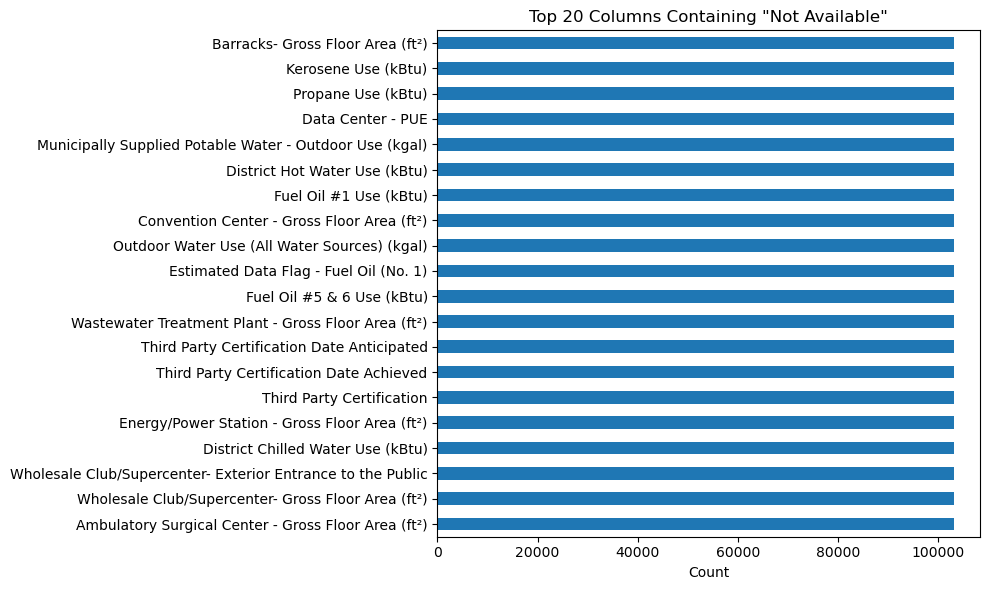

In [63]:
if len(not_available_counts) > 0:
  plt.figure(figsize=(10, 6))

  not_available_counts.head(20).sort_values().plot(kind="barh")
  plt.title('Top 20 Columns Containing "Not Available"')
  plt.xlabel("Count")
  plt.tight_layout()
  plt.show()

**Takeaway:** The raw data uses `Not Available` as a placeholder in many columns. This means true missingness is understated in the original dataset and should be reassessed after standardizing these placeholders.

In [68]:
# Create shared-cleaned data
df_shared = df.replace("Not Available", np.nan).infer_objects(copy=False).copy()

/var/folders/4f/6jnm_f3j7nj7w5jj9_61s9y40000gn/T/ipykernel_70963/1464175755.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_shared = df.replace("Not Available", np.nan).infer_objects(copy=False).copy()


In [70]:
# Missingness after shared cleaning
missing_summary = pd.DataFrame({
  "missing_count": df_shared.isna().sum(),
  "missing_rate": df_shared.isna().mean()
}).sort_values("missing_rate", ascending=False)

missing_summary.head(20)

,missing_count,missing_rate
Barracks- Gross Floor Area (ft²),103259,1.000000
Kerosene Use (kBtu),103259,1.000000
Propane Use (kBtu),103258,0.999990
Institutional Property? (Y/N),103258,0.999990
Data Center - PUE,103257,0.999981
Municipally Supplied Potable Water - Outdoor Use (kgal),103249,0.999903
ENERGY STAR Certification - Application Status,103246,0.999874
District Hot Water Use (kBtu),103246,0.999874
Fuel Oil #1 Use (kBtu),103242,0.999835
Convention Center - Gross Floor Area (ft²),103240,0.999816


**Takeaway:** After converting `Not Available` to missing values, several columns become extremely sparse or nearly empty. This suggests that the dataset contains many domain-specific fields that only apply to a small subset of properties, so task-specific column filtering will be necessary later.

In [73]:
# Duplicate check
duplicate_count = df_shared.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


**Takeaway:** No fully duplicated rows were found in the shared-cleaned dataset, so duplicate removal does not appear to be a major issue at the dataset level.

### 4. Descriptive Statistics

In [76]:
shared_numeric = [
  "Year Built",
  "Property GFA - Self-Reported (ft²)",
  "Number of Buildings"
]

In [78]:
for col in shared_numeric:
  if col in df_shared.columns:
      df_shared[col] = pd.to_numeric(df_shared[col].astype(str).str.replace(",", "", regex=False), errors="coerce")

In [80]:
# Descriptive statistics for numeric variables
numeric_existing = [c for c in shared_numeric if c in df_shared.columns]

numeric_summary = df_shared[numeric_existing].describe().T
numeric_summary["missing_count"] = df_shared[numeric_existing].isna().sum()
numeric_summary["missing_rate"] = df_shared[numeric_existing].isna().mean()

numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate
Year Built,103259.0,1951.823434,34.843372,1051.0,1926.0,1949.0,1973.0,2088.0,0,0.0
Property GFA - Self-Reported (ft²),103259.0,121126.933305,304478.289583,0.0,34580.0,58765.0,112500.0,21150159.0,0,0.0
Number of Buildings,103259.0,1.348386,4.871286,0.0,1.0,1.0,1.0,514.0,0,0.0


In [49]:
shared_categorical = [
  "Primary Property Type - Self Selected"
]

In [51]:
# Descriptive statistics for categorical variable
cat_col = "Primary Property Type - Self Selected"

type_summary = pd.DataFrame({
  "count": df_shared[cat_col].value_counts(dropna=False),
  "proportion": df_shared[cat_col].value_counts(dropna=False, normalize=True)
})

print("Number of unique categories:", df_shared[cat_col].nunique(dropna=True))
type_summary.head(15)

Number of unique categories: 84


,count,proportion
Primary Property Type - Self Selected,,
Multifamily Housing,68696,0.665279
Office,7621,0.073805
K-12 School,5754,0.055724
Hotel,1995,0.019320
Non-Refrigerated Warehouse,1434,0.013887
College/University,1320,0.012783
Manufacturing/Industrial Plant,1264,0.012241
Retail Store,1032,0.009994
Self-Storage Facility,916,0.008871


**Takeaway:** The shared numerical variables vary substantially in scale, and Number of Buildings is concentrated at small values with a long right tail.

### 5. Distribution Checks

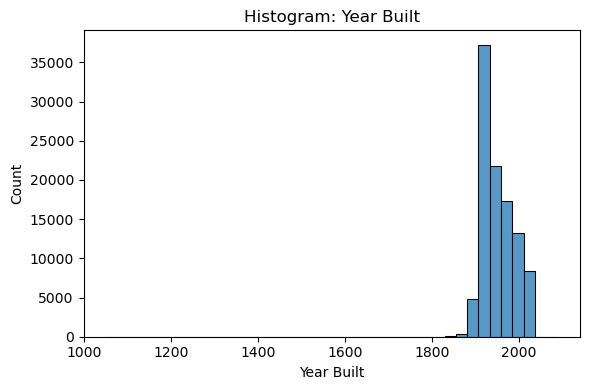

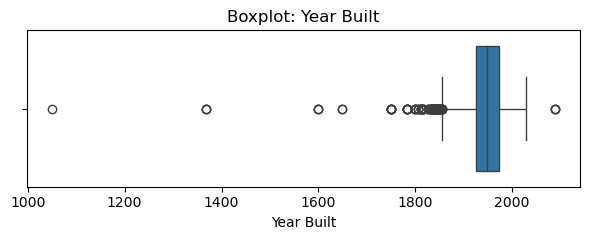

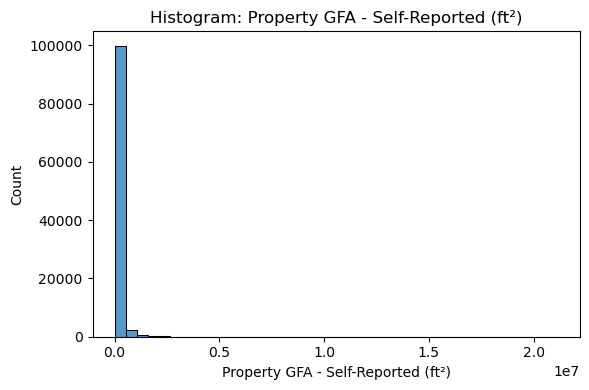

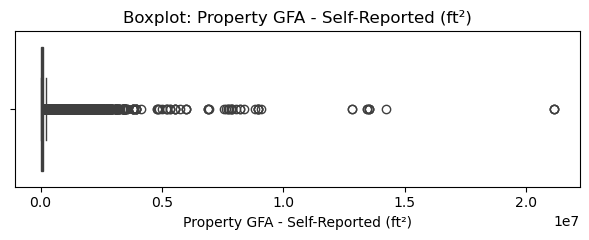

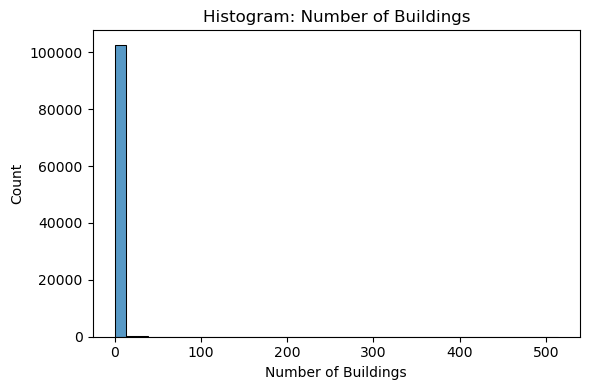

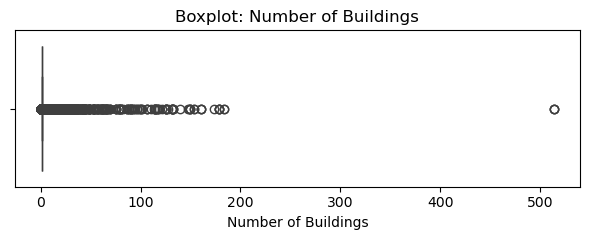

In [54]:
# Distribution checks for numeric variables 
for col in numeric_existing:
  series = df_shared[col].dropna()

  plt.figure(figsize=(6, 4))
  sns.histplot(series, bins=40, kde=False)
  plt.title(f"Histogram: {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(6, 2.5))
  sns.boxplot(x=series)
  plt.title(f"Boxplot: {col}")
  plt.xlabel(col)
  plt.tight_layout()
  plt.show()

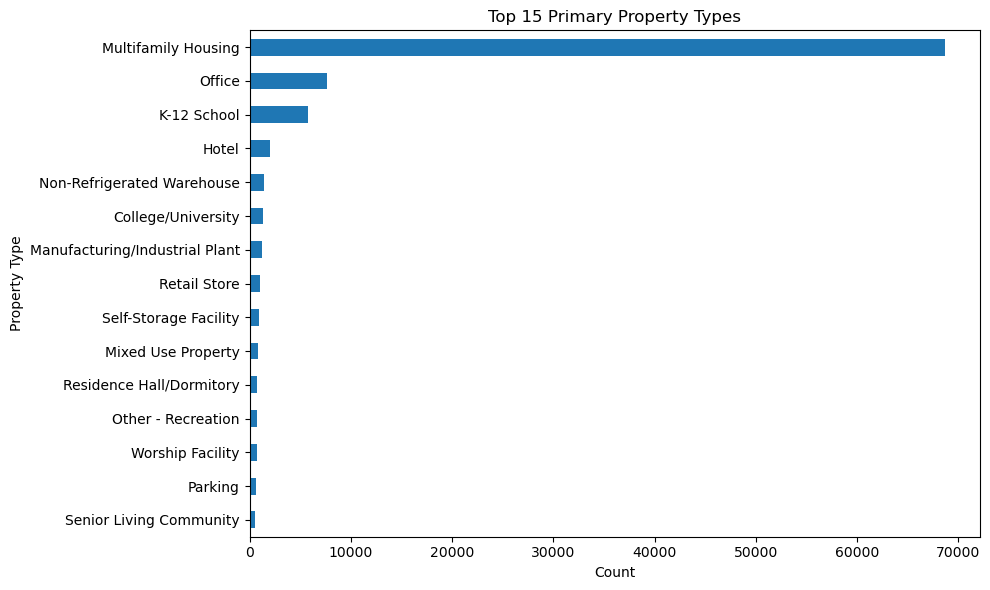

In [56]:
# Distribution checks for categorical values
plt.figure(figsize=(10, 6))
df_shared[cat_col].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Primary Property Types")
plt.xlabel("Count")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

**Takeaway:** The plots confirm skewness and possible extreme values in shared numeric variables, especially Property GFA and Number of Buildings, while property types are strongly imbalanced.

### 6. Shared Cleaning Rules
Based on the shared EDA, the team will use the following common preprocessing rules:
  1. Replace placeholder values such as `Not Available` with missing values (`NaN`).
  2. Reassess missingness after placeholder conversion because raw null counts alone understate data sparsity.
  3. Apply basic numeric type conversion to common shared-analysis variables such as `Year Built`, `Property GFA - Self-Reported (ft²)`, and `Number of Buildings`.
  4. Do not use identifier-like columns as modeling features unless they are specifically needed for grouping or interpretation.
  5. Keep the shared EDA limited to common data understanding, and perform target-specific preprocessing only in each member's own task notebook.

### 7. Shared Findings
The shared EDA shows that this dataset is rich enough to support multiple machine learning tasks, including regression, classification, and clustering, because it contains building characteristics, energy indicators, water indicators, and emissions-related variables.

At the same time, the dataset requires careful preprocessing. A large portion of the columns are non-numeric, many fields use `Not Available` as a placeholder, and several columns become highly sparse after placeholder standardization. This indicates that the dataset is wide and heterogeneous, and many variables only apply to a subset of properties.

The shared numerical variables also show clear distribution issues. `Number of Buildings` is highly right-skewed, and `Year Built` includes potentially suspicious values that may need task-specific review later. The categorical distribution is also imbalanced, with `Multifamily Housing` accounting for about 66.5% of the records.

Based on these findings, the team will use a common preprocessing approach at the shared level: standardize placeholder values, inspect missingness after cleaning, and treat only a small set of common variables as shared analysis variables. After this shared EDA, each team member will continue with task-specific EDA using their own target variable and feature subset.

### 8. Export Shared-Cleaned Dataset
This shared-cleaned dataset is exported as the common starting point for all team members' individual EDA and preprocessing. It includes placeholder standardization (`Not Available` to `NaN`) but does not apply any task-specific filtering, imputation, or encoding.

In [106]:
output_path = "NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv"
df_shared.to_csv(output_path, index=False)

print("Exported shared-cleaned dataset to:", output_path)

Exported shared-cleaned dataset to: NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv
